# Visualizing AR catalogs   
Created by Michelle L. Maclennan   
14 March 2024

In [1]:
# Libraries 
import csv
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

## Mapping ARs

In [2]:
# Read a single AR catalog 
path = '~/extreme_antarctic_ARs/data/ar_catalogs/'
fn = 'MERRA2.ar_tag.Wille_v2.4_vIVT.3hourly.19800101-19801231.nc' # the files are annual, so this is just ARs in 1980
ds = xr.open_mfdataset(path+fn)

#### What does the dataset look like?   
ar_binary_tag is the AR catalog. It's a binary dataset with time, latitude, and longitude coordinates. At each grid point in time, an AR is either present, i.e. value == 1, or it is not (which is more likely since they are rare) with value == 0. 

#### Plot ARs at a few timesteps   
As you can see from the maps below, ARs occur somewhat sporadically. Sometimes there is more than one AR at the same time, just over different parts of the Southern Ocean. Sometimes we can get a series of multiple ARs in a row, called an AR family.

In [3]:
# Select the time frame we want to plot 
ar_binary_tag = ds.ar_binary_tag.sel(time=slice('1980-01-01T18:00','1980-01-07T18:00'))

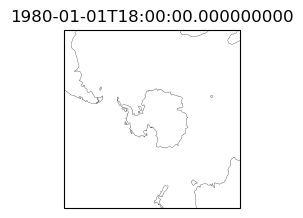

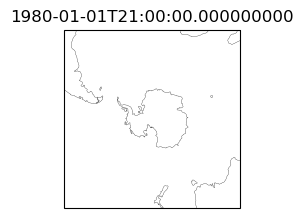

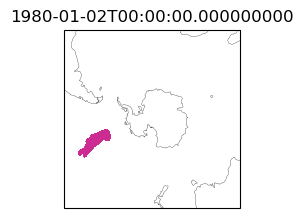

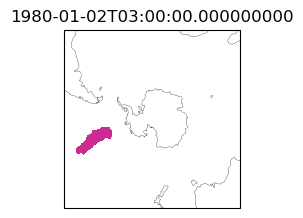

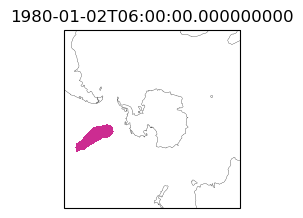

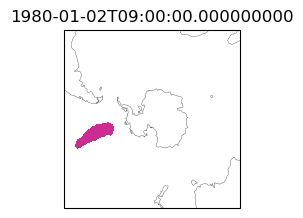

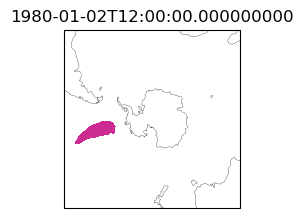

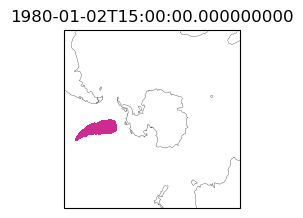

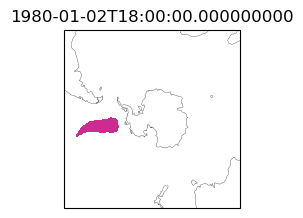

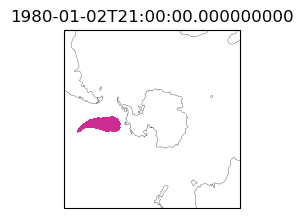

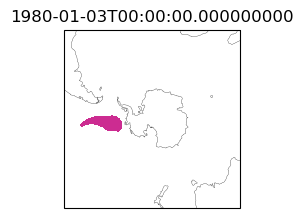

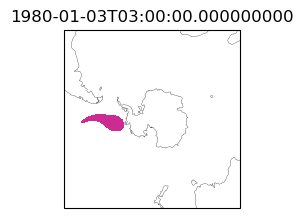

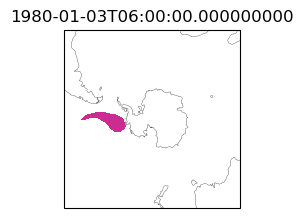

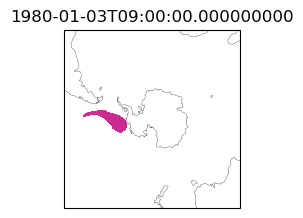

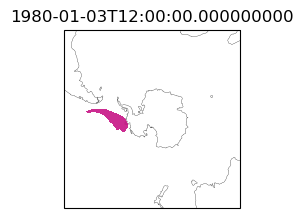

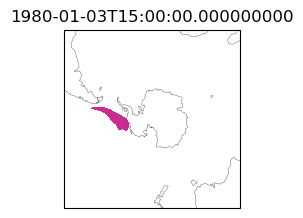

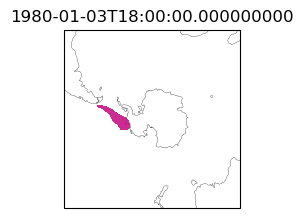

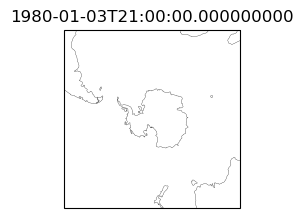

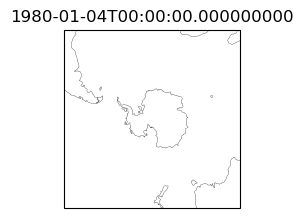

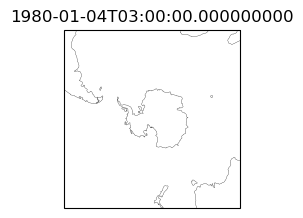

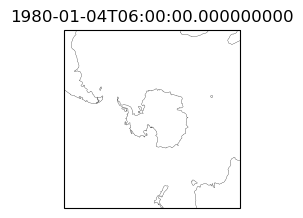

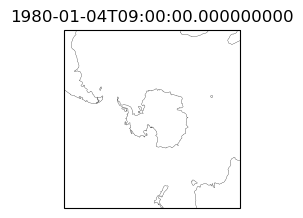

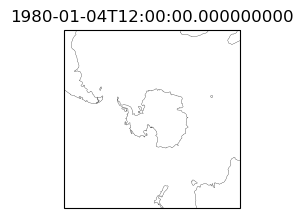

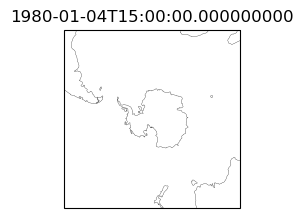

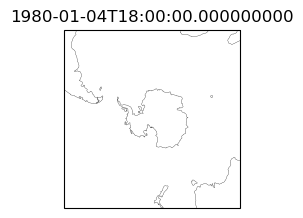

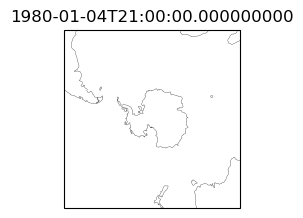

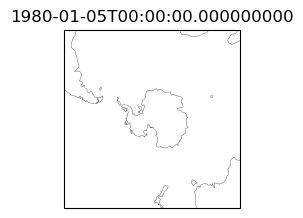

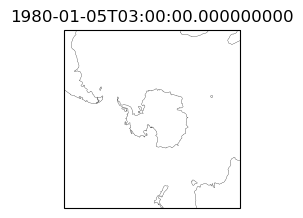

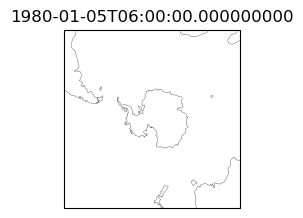

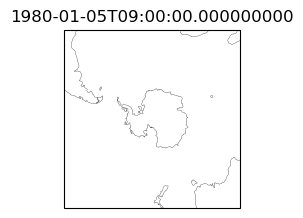

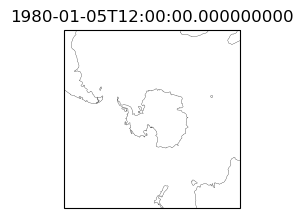

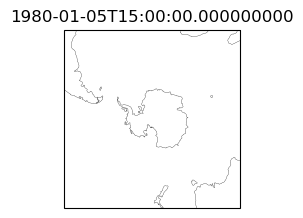

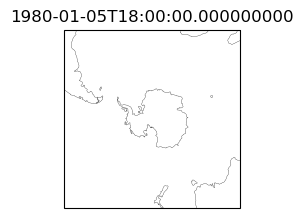

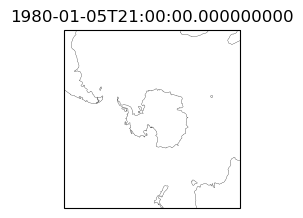

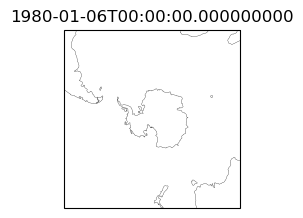

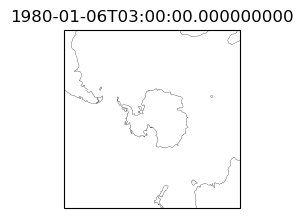

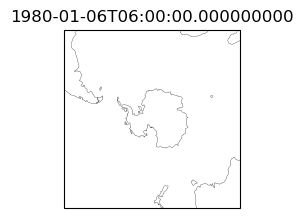

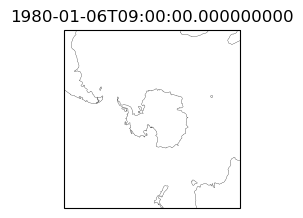

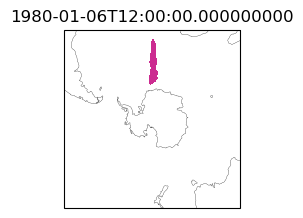

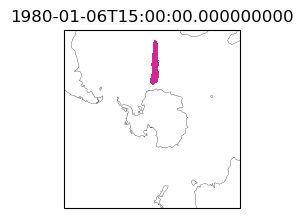

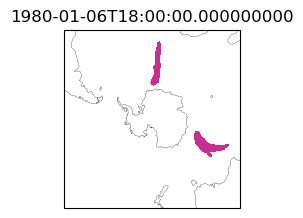

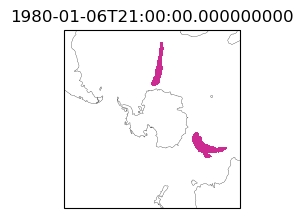

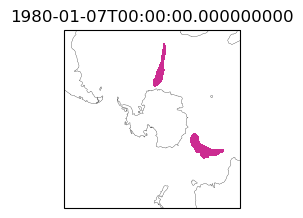

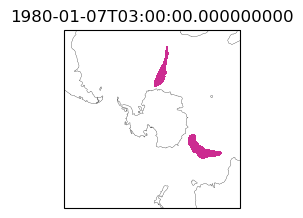

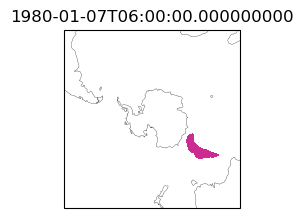

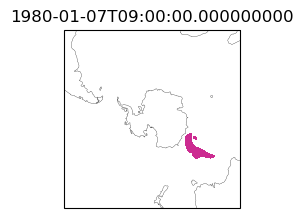

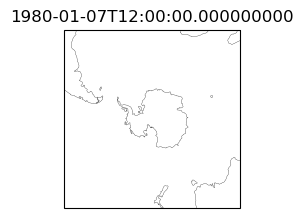

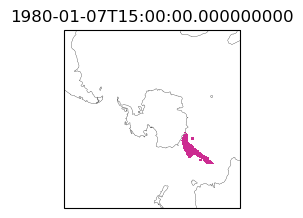

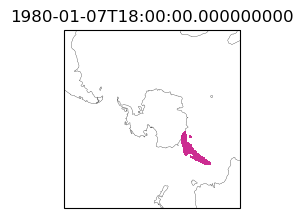

In [4]:
# Plot ARs at each timestep 

for i in range(len(ar_binary_tag.time)):
    plt.figure(figsize=(5,5))
    # Setting up the map - we're using a polar stereographic projection 
    ax1 = plt.subplot( 121, projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.) )
    ax1.set_extent([-180,180,-90,-35], ccrs.PlateCarree())
    ax1.coastlines(resolution='110m',linewidth=0.2,zorder=14)
    # Plotting the ARs 
    colormap = matplotlib.colors.ListedColormap(['mediumvioletred'])
    levels = np.array([0.5,1.5]) # levels for the colormap 
    CS = ax1.contourf(ds.lon,ds.lat,ar_binary_tag[i,:,:],levels,cmap=colormap,alpha=0.9,zorder=14,transform=ccrs.PlateCarree()) # cmap=colormap, Blues, YlGnBu_r, norm=matplotlib.colors.LogNorm()
    # cbar = plt.colorbar(CS,fraction=0.04, pad=0.04) # we don't really need the colorbar plotted because it's a binary value
    plt.title(ar_binary_tag.time[i].values) # plot the timestep 
    plt.show()

## Mapping the March 2022 AR-heatwave event    
Heatwave paper, for reference: https://journals.ametsoc.org/view/journals/clim/37/3/JCLI-D-23-0175.1.xml

In [5]:
# Read the 2022 AR catalog 
path = '~/extreme_antarctic_ARs/data/ar_catalogs/'
fn = 'MERRA2.ar_tag.Wille_v2.4_vIVT.3hourly.20220101-20221231.nc' # the files are annual
ds2 = xr.open_mfdataset(path+fn)

#### Select the heatwave event (March 15-19, 2022) and plot AR catalog

You can see from the figure below just how big this AR was - it covers an enormous area of the ice sheet and it lasts for a while.

In [6]:
# Select the time frame we want to plot 
ar_binary_tag2 = ds2.ar_binary_tag.sel(time=slice('2022-03-15T00:00','2022-03-18T12:00'))

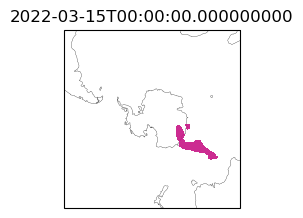

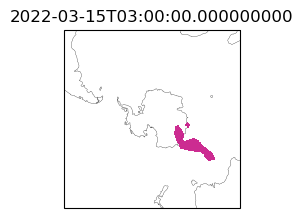

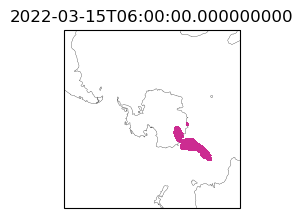

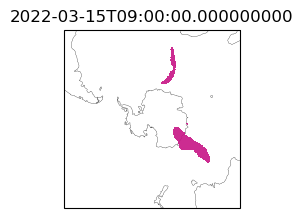

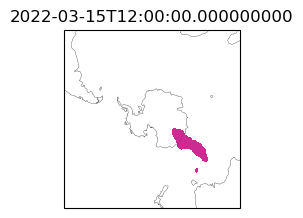

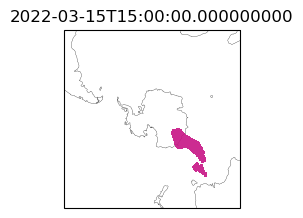

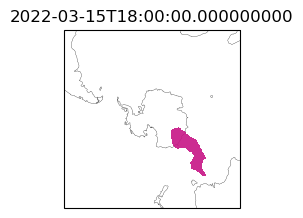

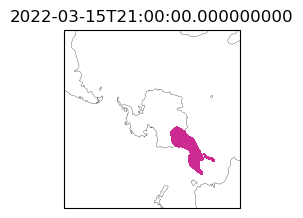

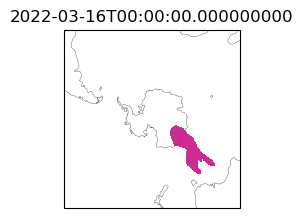

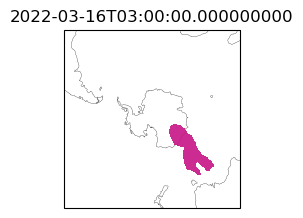

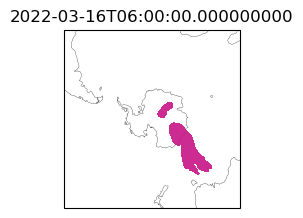

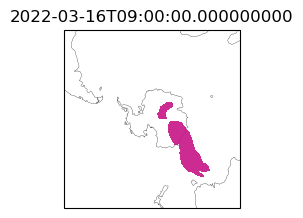

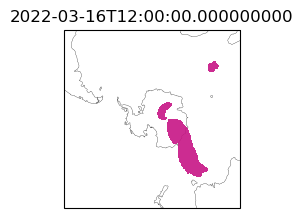

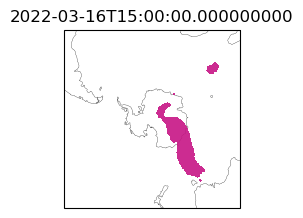

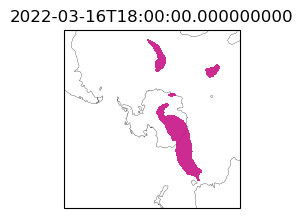

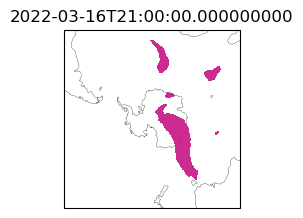

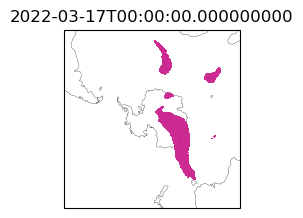

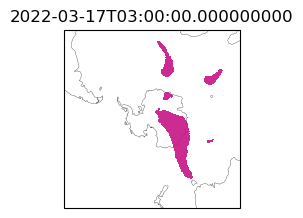

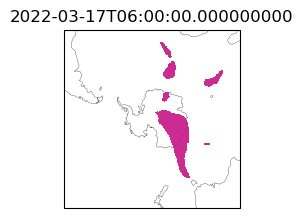

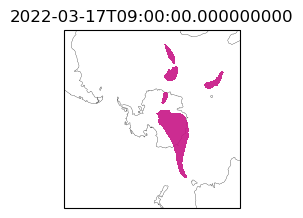

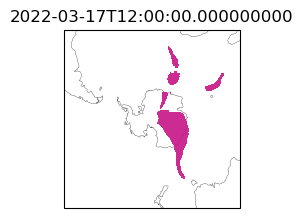

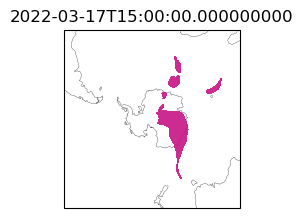

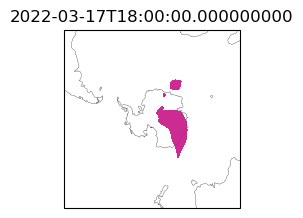

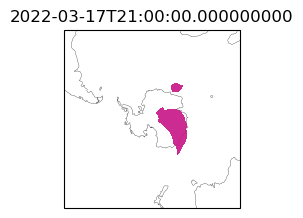

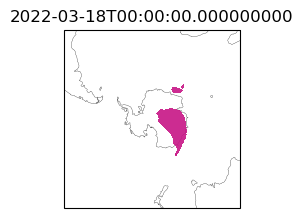

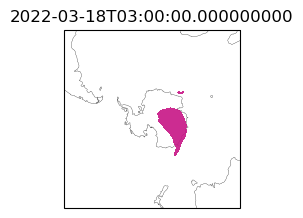

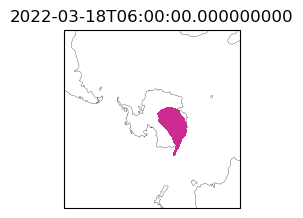

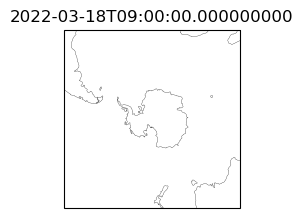

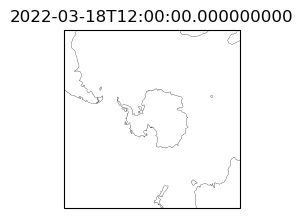

In [7]:
# Plot ARs at each timestep 

for i in range(len(ar_binary_tag2.time)):
    plt.figure(figsize=(5,5))
    # Setting up the map - we're using a polar stereographic projection 
    ax1 = plt.subplot( 121, projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.) )
    ax1.set_extent([-180,180,-90,-35], ccrs.PlateCarree())
    ax1.coastlines(resolution='110m',linewidth=0.2,zorder=14)
    # Plotting the ARs 
    colormap = matplotlib.colors.ListedColormap(['mediumvioletred'])
    levels = np.array([0.5,1.5]) # levels for the colormap 
    CS = ax1.contourf(ds2.lon,ds2.lat,ar_binary_tag2[i,:,:],levels,cmap=colormap,alpha=0.9,zorder=14,transform=ccrs.PlateCarree()) # cmap=colormap, Blues, YlGnBu_r, norm=matplotlib.colors.LogNorm()
    # cbar = plt.colorbar(CS,fraction=0.04, pad=0.04) # we don't really need the colorbar plotted because it's a binary value
    plt.title(ar_binary_tag2.time[i].values) # plot the timestep 
    plt.show()

## Mapping AR frequency    

A map of AR frequency is a way to look at how often ARs occur in different parts of Antarctica. When you plot the AR catalog timestep-by-timestep, like we did above, it's easy to think that ARs occur pretty regularly - you see one pop up every few days on the map. But when you look at the annual frequency of ARs, you can see that at any given location along the Antarctic coastline, they only occur ~1% of the time. 

#### Read all AR catalogs, 1980-2022

In [8]:
# Read all catalogs 1980-2022
path = '~/extreme_antarctic_ARs/data/ar_catalogs/'
fn = 'MERRA2.ar_tag.Wille_v2.4_vIVT.3hourly.*.nc'
ds3 = xr.open_mfdataset(path+fn,combine='nested',concat_dim="time")

#### Calculate AR frequency 

There are a couple of ways to calculate annual AR frequency. I like the method of calculating the frequency of ARs each year, then taking the mean and standard deviation - this gives you a better sense of the variability. But the easier/faster way is just to take the total frequency over the time period, which I'm showing here. Overall these two methods actually produce extremely similar values for AR frequency, so it's not always necessary to do it the first way. 

In [9]:
# Take the AR catalog and sum it over all time 
ar_binary_tag_sum = np.sum(ds3.ar_binary_tag,axis=0)

# Calculate the number of timesteps 
timesteps = len(ds3.time)

# Divide the summed catalog by the number of timesteps 
# Warning -- takes a good amount of memory/some time to run 
ar_freq = (ar_binary_tag_sum/timesteps).load()*100 # I like to load the data here for easier plotting


#### Plot AR frequency map  

It's important to note that the AR catalog only goes to 85S, so while I didn't do it here, I typically plot a grey circle over the South Pole to shade out that area, making it clear there aren't any ARs there. 

In [10]:
# Add cyclic point - otherwise the map plots a funk gap/line at 180 east 
ar_freq_cyc,lon_cyc = add_cyclic_point(ar_freq,ds3.lon)

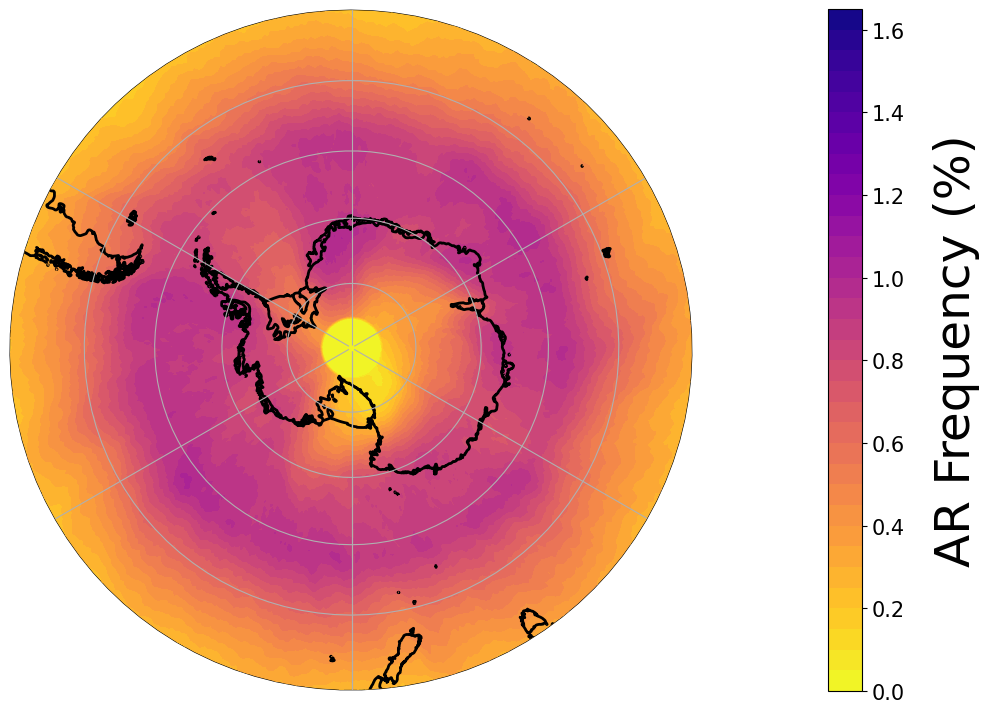

In [11]:
# Map AR frequency

# Map format 
# The first time you run the add_feature lines, it takes some time
# Plotting info for coastline and ice shelves: https://notebook.community/hetland/python4geosciences/materials/5_maps
fig = plt.figure(figsize=(10,10))
ax = plt.subplot(1, 1, 1, projection=ccrs.SouthPolarStereo(central_longitude = 0))
ax.set_extent([-180,180, -90, -40],ccrs.PlateCarree())
ocean_50m = cfeature.NaturalEarthFeature('physical', 'ocean', '50m',edgecolor='lightblue',facecolor='lightblue') # 10m, 50m, 110m # edgecolor lightblue
ax.add_feature(ocean_50m,linewidth=3)
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',edgecolor='none',facecolor='white') # 10m, 50m, 110m
ax.add_feature(land_50m,linewidth=3)
ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='white') # 10m, 50m, 110m
ax.add_feature(ice_shelf_poly,linewidth=3)
ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
ax.add_feature(ice_shelf_line,linewidth=2,zorder=13)
ax.coastlines(resolution='50m',linewidth=2,zorder=14)

# Map extent 
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# AR frequency map 
levels = np.arange(0,1.7,0.05)
CS = ax.contourf(lon_cyc,ds3.lat,ar_freq_cyc,levels,cmap='plasma_r',alpha=1.0,zorder=12,transform=ccrs.PlateCarree()) # cmap=colormap, Blues, YlGnBu_r, norm=matplotlib.colors.LogNorm()
cbar = plt.colorbar(CS,fraction=0.04, pad=0.16) # fraction=0.046, pad=0.04
cbar.ax.tick_params(labelsize=15)
cbar.ax.set_ylabel("AR Frequency (%)",labelpad=20,fontsize=35)

ax.gridlines(zorder=30)
plt.tight_layout()
plt.show()